### Stock Market Prediction And Forecasting Using Stacked LSTM

In [1]:
### Keras and Tensorflow >2.0

In [ ]:
### Data Collection
import pandas_datareader as pdr
import pandas as pd
import requests
import yfinance

In [12]:
import yfinance as yf
symbol = 'AAPL'

df = yf.Ticker(f"{symbol}")
df = df.history(period="max")

df


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1980-12-12 00:00:00-05:00,0.098726,0.099155,0.098726,0.098726,469033600,0.0,0.0
1980-12-15 00:00:00-05:00,0.094005,0.094005,0.093575,0.093575,175884800,0.0,0.0
1980-12-16 00:00:00-05:00,0.087136,0.087136,0.086707,0.086707,105728000,0.0,0.0
1980-12-17 00:00:00-05:00,0.088853,0.089282,0.088853,0.088853,86441600,0.0,0.0
1980-12-18 00:00:00-05:00,0.091429,0.091858,0.091429,0.091429,73449600,0.0,0.0
...,...,...,...,...,...,...,...
2025-04-07 00:00:00-04:00,177.199997,194.149994,174.619995,181.460007,160466300,0.0,0.0
2025-04-08 00:00:00-04:00,186.699997,190.339996,169.210007,172.419998,120859500,0.0,0.0
2025-04-09 00:00:00-04:00,171.949997,200.610001,171.889999,198.850006,184395900,0.0,0.0


In [13]:
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1980-12-12 00:00:00-05:00,0.098726,0.099155,0.098726,0.098726,469033600,0.0,0.0
1980-12-15 00:00:00-05:00,0.094005,0.094005,0.093575,0.093575,175884800,0.0,0.0
1980-12-16 00:00:00-05:00,0.087136,0.087136,0.086707,0.086707,105728000,0.0,0.0
1980-12-17 00:00:00-05:00,0.088853,0.089282,0.088853,0.088853,86441600,0.0,0.0
1980-12-18 00:00:00-05:00,0.091429,0.091858,0.091429,0.091429,73449600,0.0,0.0


In [14]:
df.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-04-07 00:00:00-04:00,177.199997,194.149994,174.619995,181.460007,160466300,0.0,0.0
2025-04-08 00:00:00-04:00,186.699997,190.339996,169.210007,172.419998,120859500,0.0,0.0
2025-04-09 00:00:00-04:00,171.949997,200.610001,171.889999,198.850006,184395900,0.0,0.0
2025-04-10 00:00:00-04:00,189.070007,194.779999,183.000000,190.419998,121880000,0.0,0.0
2025-04-11 00:00:00-04:00,186.100006,199.539993,186.059998,198.149994,87300000,0.0,0.0


In [15]:
df1=df.reset_index()['Close']

In [16]:
df1

0          0.098726
1          0.093575
2          0.086707
3          0.088853
4          0.091429
            ...    
11169    181.460007
11170    172.419998
11171    198.850006
11172    190.419998
11173    198.149994
Name: Close, Length: 11174, dtype: float64

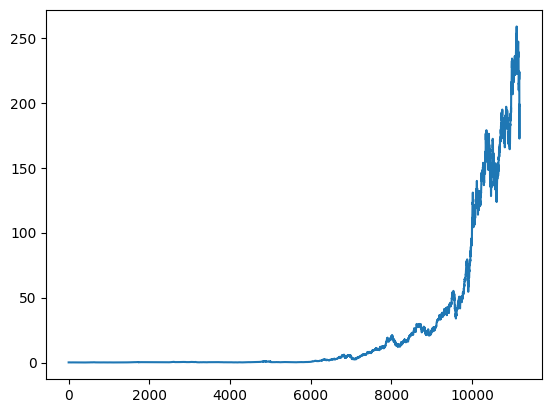

In [18]:
import matplotlib.pyplot as plt
plt.plot(df1)
plt.show()

In [ ]:
### LSTM are sensitive to the scale of the data. so we apply MinMax scaler 

In [19]:
import numpy as np

In [20]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

In [21]:
print(df1)

[[2.35613214e-04]
 [2.15703458e-04]
 [1.89154131e-04]
 ...
 [7.68511700e-01]
 [7.35925376e-01]
 [7.65805792e-01]]


In [22]:
##splitting dataset into train and test split
training_size=int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1),:1]

In [23]:
training_size,test_size

(7263, 3911)

In [24]:
train_data

array([[0.00023561],
       [0.0002157 ],
       [0.00018915],
       ...,
       [0.02131404],
       [0.02143269],
       [0.02123726]])

In [25]:
import numpy
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100 
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)

In [33]:
# reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

In [34]:
print(X_train.shape), print(y_train.shape)

(7162, 100)
(7162,)


(None, None)

In [35]:
print(X_test.shape), print(ytest.shape)

(3810, 100)
(3810,)


(None, None)

In [36]:
# reshape input to be [samples, time steps, features] which is required for LSTM
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [37]:
### Create the Stacked LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [38]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')


/Users/tilakpatel/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=100,batch_size=64,verbose=1)

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - loss: 4.6659e-05 - val_loss: 0.0087
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - loss: 3.4051e-07 - val_loss: 0.0063
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 3.7324e-07 - val_loss: 0.0072
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - loss: 3.8046e-07 - val_loss: 0.0058
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 3.9491e-07 - val_loss: 0.0065
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 3.0416e-07 - val_loss: 0.0056
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 2.9591e-07 - val_loss: 0.0027
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 3.3189e-07 - val_loss: 0.0049
Epoch 9/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 2.1648e-07 - val_loss: 0.0051
Epoch 10/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - loss: 2.8370e-07 - val_loss: 0.0049
Epoch 11/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - loss: 3.77

In [42]:
import tensorflow as tf

In [43]:
tf.__version__

'2.18.0'

In [44]:
### Lets Do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


In [45]:
##Transformback to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [46]:
### Calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

1.3680765565940498

In [47]:
### Test Data RMSE
math.sqrt(mean_squared_error(ytest,test_predict))

82.05725527604979

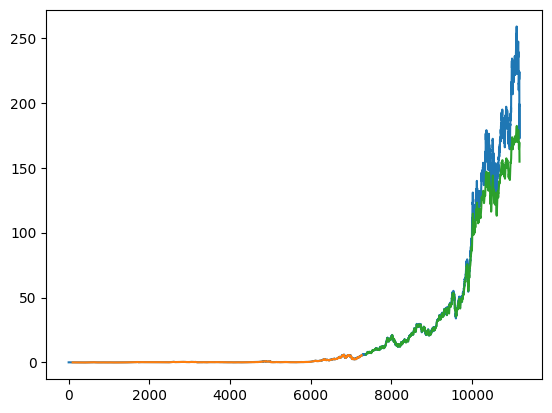

In [48]:
### Plotting 
# shift train predictions for plotting
look_back=100
trainPredictPlot = numpy.empty_like(df1)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = numpy.empty_like(df1)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1, :] = test_predict
# plot baseline and predictions
plt.plot(scaler.inverse_transform(df1))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [59]:
len(test_data)

3911

In [60]:
x_input=test_data[len(test_data)-100:].reshape(1,-1)
x_input.shape


(1, 100)

In [61]:
temp_input=list(x_input)
temp_input=temp_input[0].tolist()

In [62]:
temp_input

[0.8686396663320183,
 0.8803007392981724,
 0.8813046313270033,
 0.8840847398397483,
 0.8822313734866386,
 0.8874440622022653,
 0.899027867333063,
 0.9074840356412522,
 0.9069820896268368,
 0.916249157324707,
 0.924975586107403,
 0.9367910767781094,
 0.9381811310344819,
 0.9382969738044363,
 0.9375247083324337,
 0.952622312513381,
 0.9565607897425896,
 0.9516183615014696,
 0.9572944802799943,
 0.9579508439989621,
 0.9691871208198964,
 0.9786086062223189,
 0.9576419496067772,
 0.9643605353487308,
 0.9825085675000101,
 0.985520361552664,
 0.9968339062089548,
 1.0,
 0.9867559391214037,
 0.9736662369642793,
 0.9667931745346929,
 0.9414246696101249,
 0.9395326103562566,
 0.9458650928537491,
 0.9350921871126324,
 0.93698412840034,
 0.9143957319885169,
 0.9049356126684162,
 0.9006109732116659,
 0.9183342092177256,
 0.8812274224747272,
 0.8878687993644048,
 0.8595270753217807,
 0.8641219752530376,
 0.8634656115340699,
 0.8600676552538745,
 0.8874054282845871,
 0.9198401062440524,
 0.92408753684

In [63]:
# demonstrate prediction for next 10 days
from numpy import array

lst_output=[]
n_steps=100
i=0
while(i<30):
    
    if(len(temp_input)>100):
        #print(temp_input)
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)
        x_input = x_input.reshape((1, n_steps, 1))
        #print(x_input)
        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        #print(temp_input)
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        x_input = x_input.reshape((1, n_steps,1))
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])
        temp_input.extend(yhat[0].tolist())
        print(len(temp_input))
        lst_output.extend(yhat.tolist())
        i=i+1
    

print(lst_output)

[0.58952475]
101
1 day input [0.88030074 0.88130463 0.88408474 0.88223137 0.88744406 0.89902787
 0.90748404 0.90698209 0.91624916 0.92497559 0.93679108 0.93818113
 0.93829697 0.93752471 0.95262231 0.95656079 0.95161836 0.95729448
 0.95795084 0.96918712 0.97860861 0.95764195 0.96436054 0.98250857
 0.98552036 0.99683391 1.         0.98675594 0.97366624 0.96679317
 0.94142467 0.93953261 0.94586509 0.93509219 0.93698413 0.91439573
 0.90493561 0.90061097 0.91833421 0.88122742 0.8878688  0.85952708
 0.86412198 0.86346561 0.86006766 0.88740543 0.91984011 0.92408754
 0.91725305 0.91111368 0.88026211 0.89875761 0.8974834  0.90037935
 0.87879484 0.87983849 0.8990501  0.91547854 0.93349186 0.94535902
 0.94485648 0.94640266 0.95011359 0.94903125 0.95502281 0.95479083
 0.92896921 0.91714075 0.93469016 0.91996256 0.91184495 0.91111055
 0.90952568 0.92398272 0.87918136 0.85351434 0.83859345 0.81037518
 0.82510284 0.82707423 0.82201042 0.83186749 0.82746081 0.84358
 0.85308913 0.864763   0.85618156 0.

In [64]:
day_new=np.arange(1,101)
day_pred=np.arange(101,131)

In [65]:
import matplotlib.pyplot as plt

In [66]:
len(df1)

11174

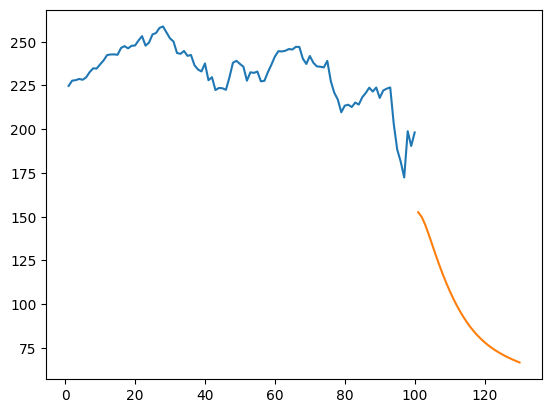

In [67]:
plt.plot(day_new,scaler.inverse_transform(df1[len(df1)-100:]))
plt.plot(day_pred,scaler.inverse_transform(lst_output))

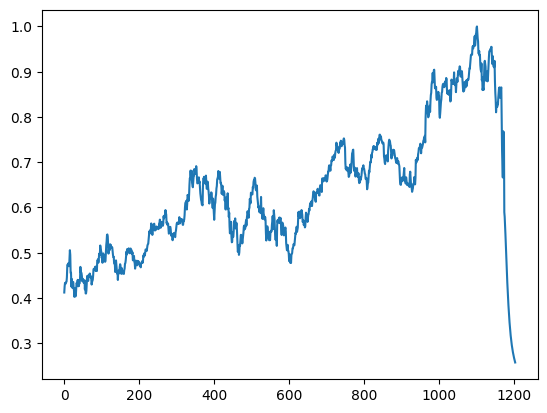

In [70]:
df3=df1.tolist()
df3.extend(lst_output)
plt.plot(df3[10000:])

In [71]:
df3=scaler.inverse_transform(df3).tolist()

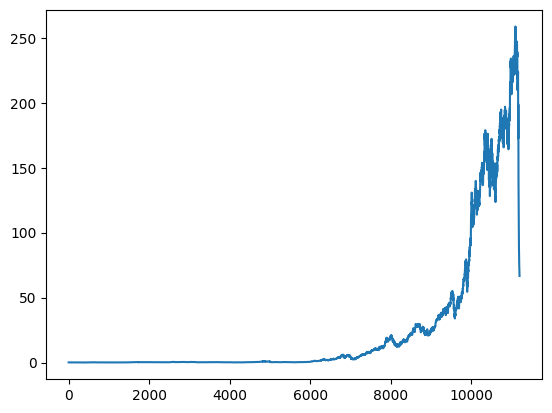

In [72]:
plt.plot(df3)